# 05 - Autoencoder-Based Feature Selection

## Objective

Use an **Autoencoder implemented with scikit-learn's `MLPRegressor`** to learn a compact representation of the preprocessed patient data and derive feature importance from the encoder weights.

The selected feature sets will be created at the requested cumulative-importance thresholds:

- **85%**
- **90%**
- **91.05%**

The selected feature sets will later be evaluated using **Random Forest and XGBoost**.

### Leakage control

- `diagnosed_diabetes` is the target and is not used as an input feature.
- `diabetes_stage` is excluded because it was identified as a leakage-prone feature.
- The Autoencoder is trained without the target variable.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

np.random.seed(42)

print("scikit-learn Autoencoder setup ready.")


scikit-learn Autoencoder setup ready.


In [2]:
# Load dataset
df = pd.read_csv("../data/diabetes_dataset.csv")

print("Dataset shape:", df.shape)


Dataset shape: (100000, 31)


In [3]:
# Prepare input features and target
target_column = "diagnosed_diabetes"
leakage_columns = ["diabetes_stage"]

X = df.drop(columns=[target_column] + leakage_columns)
y = df[target_column].astype(int)

print("Input feature count:", X.shape[1])
print("Target variable:", target_column)
print("Excluded leakage columns:", leakage_columns)


Input feature count: 29
Target variable: diagnosed_diabetes
Excluded leakage columns: ['diabetes_stage']


In [4]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 80000
Testing samples: 20000


In [5]:
# Identify feature types
numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))


Numerical features: 23
Categorical features: 6


In [6]:
# Preprocessing
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Fit only on training data to avoid leakage
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)


Processed training shape: (80000, 47)
Processed testing shape: (20000, 47)


## Autoencoder

The Autoencoder is implemented using `MLPRegressor`.

Architecture:

`47 input features → 32 neurons → 12-neuron bottleneck → 32 neurons → 47 reconstructed features`

The model learns to reconstruct the input data. The target `diagnosed_diabetes` is **not** provided to the Autoencoder.

Feature importance is derived from the absolute weights connecting the input layer to the first hidden layer. The importance values are normalized and accumulated to obtain the requested 85%, 90%, and 91.05% thresholds.


In [7]:
# Build the Autoencoder using MLPRegressor
input_dim = X_train_processed.shape[1]

autoencoder = MLPRegressor(
    hidden_layer_sizes=(32, 12, 32),
    activation="relu",
    solver="adam",
    batch_size=256,
    learning_rate_init=0.001,
    max_iter=50,
    early_stopping=True,
    validation_fraction=0.10,
    n_iter_no_change=5,
    random_state=42,
    verbose=True
)

print("Autoencoder architecture:")
print(f"Input features: {input_dim}")
print("Hidden layers: 32 → 12 → 32")
print(f"Output features: {input_dim}")


Autoencoder architecture:
Input features: 47
Hidden layers: 32 → 12 → 32
Output features: 47


In [8]:
# Train Autoencoder
autoencoder.fit(
    X_train_processed,
    X_train_processed
)

print("Autoencoder training completed.")
print("Iterations used:", autoencoder.n_iter_)
print("Final training loss:", round(autoencoder.loss_, 6))


Iteration 1, loss = 0.20704898
Validation score: 0.293038
Iteration 2, loss = 0.12001680
Validation score: 0.344292
Iteration 3, loss = 0.10300429
Validation score: 0.365734
Iteration 4, loss = 0.09867365
Validation score: 0.370787
Iteration 5, loss = 0.09436375
Validation score: 0.383370
Iteration 6, loss = 0.08957345
Validation score: 0.389937
Iteration 7, loss = 0.08812585
Validation score: 0.390411
Iteration 8, loss = 0.08770004
Validation score: 0.392567
Iteration 9, loss = 0.08742586
Validation score: 0.393051
Iteration 10, loss = 0.08721489
Validation score: 0.392410
Iteration 11, loss = 0.08706124
Validation score: 0.393314
Iteration 12, loss = 0.08699164
Validation score: 0.393214
Iteration 13, loss = 0.08686080
Validation score: 0.394045
Iteration 14, loss = 0.08678129
Validation score: 0.390551
Iteration 15, loss = 0.08674278
Validation score: 0.393339
Iteration 16, loss = 0.08664850
Validation score: 0.393477
Iteration 17, loss = 0.08663802
Validation score: 0.392640
Iterat

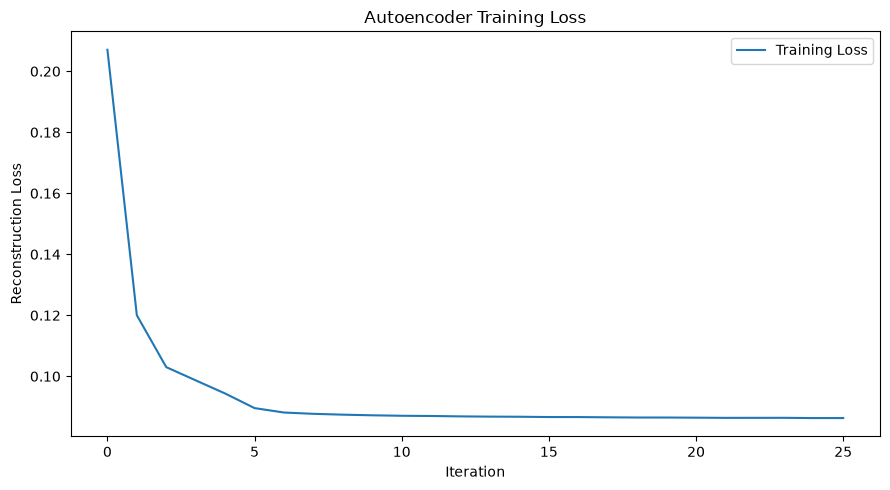

In [9]:
# Plot Autoencoder training loss
plt.figure(figsize=(9, 5))

plt.plot(
    autoencoder.loss_curve_,
    label="Training Loss"
)

plt.xlabel("Iteration")
plt.ylabel("Reconstruction Loss")
plt.title("Autoencoder Training Loss")
plt.legend()
plt.tight_layout()
plt.show()


In [10]:
# Derive feature importance from the first encoder layer
# coefs_[0] connects input features to the first hidden layer
encoder_weights = autoencoder.coefs_[0]

# Aggregate the absolute weights for each input feature
raw_importance = np.sum(np.abs(encoder_weights), axis=1)

# Normalize so that all feature importance values sum to 1
importance = raw_importance / raw_importance.sum()

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

feature_importance["Cumulative_Importance"] = (
    feature_importance["Importance"].cumsum()
)

feature_importance["Importance_Percent"] = (
    feature_importance["Importance"] * 100
)

feature_importance["Cumulative_Percent"] = (
    feature_importance["Cumulative_Importance"] * 100
)

print("Total normalized importance:",
      round(feature_importance["Importance"].sum(), 6))

feature_importance.head(20)


Total normalized importance: 1.0


,Feature,Importance,Cumulative_Importance,Importance_Percent,Cumulative_Percent
0,cat__smoking_status_Never,0.034890,0.034890,3.489031,3.489031
1,cat__gender_Female,0.034545,0.069435,3.454464,6.943495
2,cat__education_level_Highschool,0.034390,0.103825,3.439033,10.382528
3,cat__education_level_Postgraduate,0.033854,0.137680,3.385445,13.767973
4,cat__education_level_Graduate,0.032826,0.170506,3.282583,17.050556
5,cat__gender_Male,0.032708,0.203213,3.270761,20.321316
6,cat__employment_status_Employed,0.031485,0.234698,3.148500,23.469816
7,cat__education_level_No formal,0.031246,0.265944,3.124597,26.594413
8,cat__income_level_Lower-Middle,0.031055,0.296999,3.105535,29.699948
9,cat__smoking_status_Current,0.030686,0.327685,3.068601,32.768550


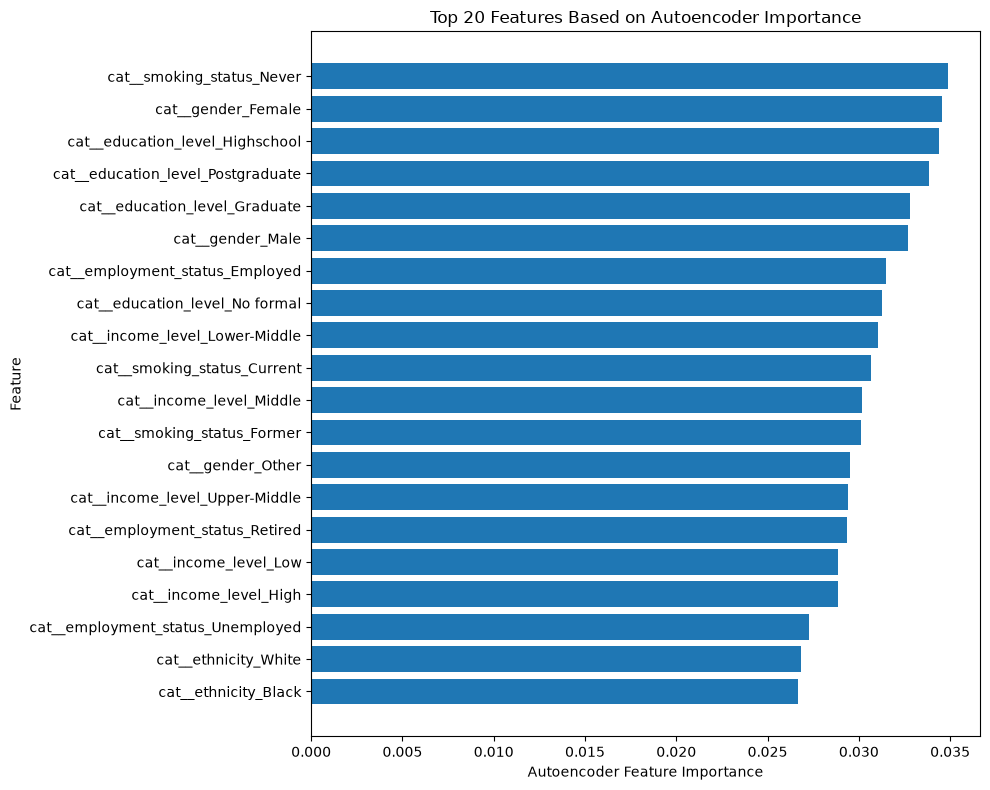

In [11]:
# Plot top 20 Autoencoder feature importance
top_features = feature_importance.head(20).sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(10, 8))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Autoencoder Feature Importance")
plt.ylabel("Feature")
plt.title("Top 20 Features Based on Autoencoder Importance")
plt.tight_layout()
plt.show()


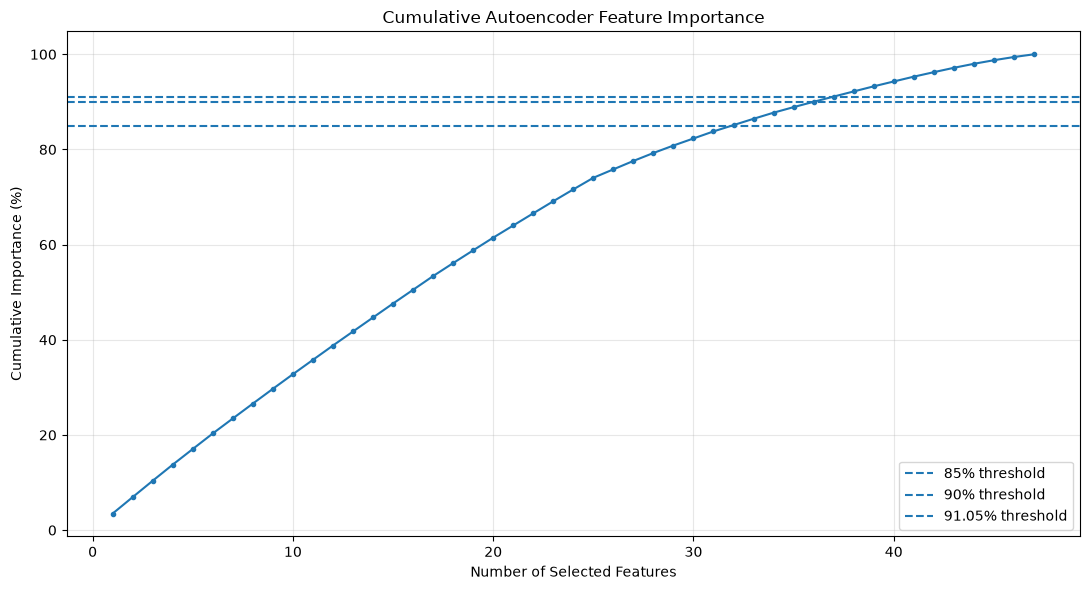

In [12]:
# Plot cumulative feature importance
plt.figure(figsize=(11, 6))

plt.plot(
    range(1, len(feature_importance) + 1),
    feature_importance["Cumulative_Percent"],
    marker="o",
    markersize=3
)

plt.axhline(85, linestyle="--", label="85% threshold")
plt.axhline(90, linestyle="--", label="90% threshold")
plt.axhline(91.05, linestyle="--", label="91.05% threshold")

plt.xlabel("Number of Selected Features")
plt.ylabel("Cumulative Importance (%)")
plt.title("Cumulative Autoencoder Feature Importance")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [13]:
# Select features required to reach each requested threshold
thresholds = {
    "85%": 0.85,
    "90%": 0.90,
    "91.05%": 0.9105
}

selected_feature_sets = {}

for name, threshold in thresholds.items():
    first_index = feature_importance.index[
        feature_importance["Cumulative_Importance"] >= threshold
    ][0]

    selected = feature_importance.loc[
        :first_index, "Feature"
    ].tolist()

    selected_feature_sets[name] = selected

selection_summary = pd.DataFrame({
    "Threshold": list(thresholds.keys()),
    "Number_of_Features": [
        len(selected_feature_sets[name])
        for name in thresholds.keys()
    ],
    "Actual_Cumulative_Importance": [
        feature_importance.loc[
            len(selected_feature_sets[name]) - 1,
            "Cumulative_Percent"
        ]
        for name in thresholds.keys()
    ]
})

selection_summary.round(4)


,Threshold,Number_of_Features,Actual_Cumulative_Importance
0,85%,32,85.1224
1,90%,36,90.0169
2,91.05%,37,91.1119


In [14]:
# Display selected features for each threshold
for name, selected in selected_feature_sets.items():
    print("\n" + "=" * 60)
    print(f"Threshold: {name}")
    print(f"Number of selected features: {len(selected)}")
    print("=" * 60)

    for i, feature in enumerate(selected, start=1):
        print(f"{i}. {feature}")



Threshold: 85%
Number of selected features: 32
1. cat__smoking_status_Never
2. cat__gender_Female
3. cat__education_level_Highschool
4. cat__education_level_Postgraduate
5. cat__education_level_Graduate
6. cat__gender_Male
7. cat__employment_status_Employed
8. cat__education_level_No formal
9. cat__income_level_Lower-Middle
10. cat__smoking_status_Current
11. cat__income_level_Middle
12. cat__smoking_status_Former
13. cat__gender_Other
14. cat__income_level_Upper-Middle
15. cat__employment_status_Retired
16. cat__income_level_Low
17. cat__income_level_High
18. cat__employment_status_Unemployed
19. cat__ethnicity_White
20. cat__ethnicity_Black
21. cat__ethnicity_Asian
22. cat__employment_status_Student
23. cat__ethnicity_Other
24. num__cardiovascular_history
25. cat__ethnicity_Hispanic
26. num__diabetes_risk_score
27. num__diet_score
28. num__family_history_diabetes
29. num__cholesterol_total
30. num__hypertension_history
31. num__ldl_cholesterol
32. num__diastolic_bp

Threshold: 90%
N

## Evaluate the selected feature sets

Random Forest and XGBoost are evaluated using the features selected by the Autoencoder at each threshold.

The same train/test split is used so the comparison is consistent with the baseline experiment.


In [15]:
from xgboost import XGBClassifier

def evaluate_model(
    model,
    X_train_data,
    X_test_data,
    y_train_data,
    y_test_data,
    model_name
):
    model.fit(X_train_data, y_train_data)

    predictions = model.predict(X_test_data)
    probabilities = model.predict_proba(X_test_data)[:, 1]

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test_data, predictions),
        "Precision": precision_score(y_test_data, predictions),
        "Recall": recall_score(y_test_data, predictions),
        "F1-Score": f1_score(y_test_data, predictions),
        "ROC-AUC": roc_auc_score(y_test_data, probabilities)
    }


In [16]:
# Evaluate RF and XGBoost for each Autoencoder threshold
all_results = []

for threshold_name, selected in selected_feature_sets.items():

    selected_indices = [
        list(feature_names).index(feature)
        for feature in selected
    ]

    X_train_selected = X_train_processed[:, selected_indices]
    X_test_selected = X_test_processed[:, selected_indices]

    rf = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

    xgb = XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        n_jobs=-1,
        eval_metric="logloss"
    )

    rf_result = evaluate_model(
        rf,
        X_train_selected,
        X_test_selected,
        y_train,
        y_test,
        f"Random Forest - {threshold_name}"
    )

    xgb_result = evaluate_model(
        xgb,
        X_train_selected,
        X_test_selected,
        y_train,
        y_test,
        f"XGBoost - {threshold_name}"
    )

    rf_result["Threshold"] = threshold_name
    xgb_result["Threshold"] = threshold_name

    rf_result["Features"] = len(selected)
    xgb_result["Features"] = len(selected)

    all_results.extend([rf_result, xgb_result])

results_df = pd.DataFrame(all_results)

results_df = results_df[
    [
        "Threshold",
        "Features",
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ]
]

results_df.round(4)


,Threshold,Features,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,85%,32,Random Forest - 85%,0.6156,0.6484,0.7850,0.7102,0.6375
1,85%,32,XGBoost - 85%,0.6266,0.6520,0.8102,0.7226,0.6481
2,90%,36,Random Forest - 90%,0.9092,0.9967,0.8515,0.9184,0.9403
3,90%,36,XGBoost - 90%,0.9098,0.9966,0.8527,0.9190,0.9385
4,91.05%,37,Random Forest - 91.05%,0.9098,0.9971,0.8521,0.9189,0.9396
5,91.05%,37,XGBoost - 91.05%,0.9098,0.9964,0.8527,0.9189,0.9396


## Feature Selection Findings

After running the notebook, record:

1. Number of features selected at **85%** cumulative importance.
2. Number of features selected at **90%** cumulative importance.
3. Number of features selected at **91.05%** cumulative importance.
4. Whether Random Forest performance improved compared with the baseline.
5. Whether XGBoost performance improved compared with the baseline.
6. Which threshold gives the best balance between feature reduction and predictive performance.

### Important note

The values **85%, 90%, and 91.05% are cumulative feature-importance thresholds**, not accuracy or ROC-AUC targets.

The Autoencoder itself is unsupervised and does not use `diagnosed_diabetes` during training.
